In [81]:
import pandas as pd
import re

In [82]:
f = open('WhatsApp Chat with 911 pilots.txt',encoding='utf-8')

In [83]:
data = f.read()

In [84]:
pattern = '\d{1,2}\/\d{1,2}\/\d{2},\s\d{1,2}:\d{2}\s(?:AM|PM)\s-\s'

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_14344\2080248840.py:1: SyntaxWarning: invalid escape sequence '\d'
  pattern = '\d{1,2}\/\d{1,2}\/\d{2},\s\d{1,2}:\d{2}\s(?:AM|PM)\s-\s'


In [85]:
messages = re.split(pattern,data)[1:]

In [86]:
import re

# Use a raw string for the pattern
pattern_for_date = r'(\d{1,2}\/\d{1,2}\/\d{2}),\s(\d{1,2}:\d{2})\u202f(AM|PM)\s-\s'
# 1. Find all matches: This returns a list of tuples like [('5/7/24', '9:15', 'PM'), ...]
dates= re.findall(pattern_for_date, data)

# 2. Join the elements of each tuple into a single string.
#    We use a list comprehension and join each tuple with ', ' (for date/time) and ' ' (for time/meridiem).
#    Note: We must explicitly add the separators back in when joining.
dates = [f"{date}, {time} {meridiem}" for date, time, meridiem in dates]



In [87]:
df = pd.DataFrame({
    'user_message':messages,
    'messages-date':dates
})
df['messages-date']=pd.to_datetime(df['messages-date'],format='%m/%d/%y, %I:%M %p')

In [88]:
users = []
messages = []
for message in df['user_message']:
    entry = re.split('([\w\W]+?):\s', message)
    if entry[1:]:# user name
        users.append(entry[1])
        messages. append(entry[2])
    else:
        users. append('group_notification' )
        messages.append(entry[0])

df['user' ] = users
df['message' ] = messages
df.drop(columns=['user_message'], inplace=True)

df.head()

<>:4: SyntaxWarning: invalid escape sequence '\w'
<>:4: SyntaxWarning: invalid escape sequence '\w'
C:\Users\DELL\AppData\Local\Temp\ipykernel_14344\3034733806.py:4: SyntaxWarning: invalid escape sequence '\w'
  entry = re.split('([\w\W]+?):\s', message)


,messages-date,user,message
0,2024-10-09 17:20:00,group_notification,Messages and calls are end-to-end encrypted. O...
1,2024-10-09 20:22:00,(MOON),Nice try diddy\n
2,2024-10-09 20:23:00,Tayyab Arshad Ai,Kya howa\n
3,2024-10-09 20:23:00,Abdul Ahad Cr,Fb pe quality chud gyi\n
4,2024-10-09 20:23:00,(MOON),Nice try diddy\n


In [95]:
df['year'] = df['messages-date'].dt.year
df['month_name'] = df['messages-date'].dt.month_name()
df['day'] = df['messages-date'].dt.day
df['hour'] = df['messages-date'].dt.hour
df['minute'] = df['messages-date'].dt.minute
df['month'] = df['messages-date'].dt.month

In [100]:
timeline = df.groupby(['year','month','month_name'])['message'].count().reset_index()
timeline

,year,month,month_name,message
0,2024,10,October,4260
1,2024,11,November,2237
2,2024,12,December,1005
3,2025,1,January,169
4,2025,2,February,654
5,2025,3,March,203
6,2025,4,April,1123
7,2025,5,May,1364
8,2025,6,June,159
9,2025,7,July,273


In [107]:
time = []
for i in range(timeline.shape[0]):
    time.append(str(timeline['month'][i]) + "-" + str(timeline['year'][i]))
timeline['time']=time
    

In [133]:
df['year'] = df['messages-date'].dt.year
df['month_name'] = df['messages-date'].dt.month_name()
df['day'] = df['messages-date'].dt.day
df['hour'] = df['messages-date'].dt.hour
df['minute'] = df['messages-date'].dt.minute
df['month'] = df['messages-date'].dt.month
df['date'] = df['messages-date'].dt.date
df['day_name'] = df['messages-date'].dt.day_name()
period = []


In [134]:
df[['day_name', 'hour']]['hour']

0        17
1        20
2        20
3        20
4        20
         ..
19779    17
19780    17
19781    22
19782    22
19783    22
Name: hour, Length: 19784, dtype: int32

In [135]:
df['hour']

0        17
1        20
2        20
3        20
4        20
         ..
19779    17
19780    17
19781    22
19782    22
19783    22
Name: hour, Length: 19784, dtype: int32

In [136]:
for hour in df[['day_name', 'hour']]['hour']:
    if hour == 23:
        period.append(str(hour) + "-" + str('00'))
    elif hour == 0:
        period.append(str('00') + "-" + str(hour + 1))
    else:
        period.append(str(hour) + "-" + str(hour + 1))



<Axes: xlabel='period', ylabel='month_name'>

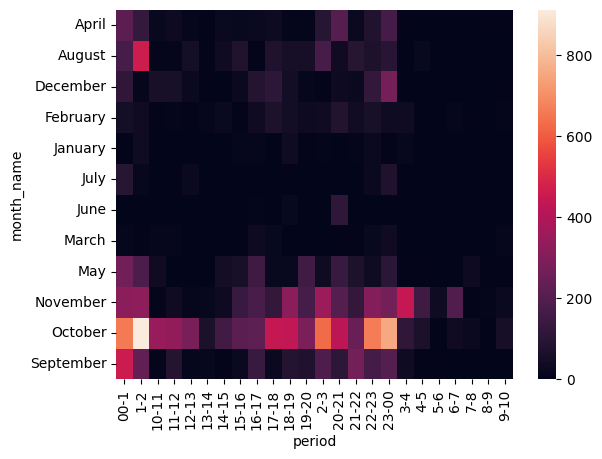

In [ ]:
import seaborn as sns 
sns.heatmap(

In [149]:
df['month_name'].value_counts()

month_name
October      7375
November     3790
September    2155
August       1503
May          1364
April        1123
December     1016
February      654
July          273
March         203
January       169
June          159
Name: count, dtype: int64

In [114]:
df

,messages-date,user,message,year,month_name,day,hour,minute,month,date
0,2024-10-09 17:20:00,group_notification,Messages and calls are end-to-end encrypted. O...,2024,October,9,17,20,10,2024-10-09
1,2024-10-09 20:22:00,(MOON),Nice try diddy\n,2024,October,9,20,22,10,2024-10-09
2,2024-10-09 20:23:00,Tayyab Arshad Ai,Kya howa\n,2024,October,9,20,23,10,2024-10-09
3,2024-10-09 20:23:00,Abdul Ahad Cr,Fb pe quality chud gyi\n,2024,October,9,20,23,10,2024-10-09
4,2024-10-09 20:23:00,(MOON),Nice try diddy\n,2024,October,9,20,23,10,2024-10-09
...,...,...,...,...,...,...,...,...,...,...
19779,2025-12-02 17:11:00,Abdul Ahad Cr,Abey bas bhej na jaldi\n,2025,December,2,17,11,12,2025-12-02
19780,2025-12-02 17:11:00,Abdul Ahad Cr,Idiot\n,2025,December,2,17,11,12,2025-12-02
19781,2025-12-02 22:41:00,Abdul Ahad Cr,<Media omitted>\n,2025,December,2,22,41,12,2025-12-02
19782,2025-12-02 22:41:00,Abdul Ahad Cr,<Media omitted>\n,2025,December,2,22,41,12,2025-12-02


In [116]:
daily = df.groupby('date')['message'].count().reset_index()


In [ ]:
daily

,date,message
0,2024-10-09,271
1,2024-10-10,207
2,2024-10-11,340
3,2024-10-12,72
4,2024-10-13,76
...,...,...
321,2025-11-28,26
322,2025-11-29,4
323,2025-11-30,2
324,2025-12-01,2
